In [1]:
from astropy.io import fits
import numpy as np
from scipy import ndimage

MAG_cube = '../data/2018_08_25/cubes/MAG_24.fits'

# ============================================================
# 1. ABRIR CUBO Y EXTRAER PRIMER FRAME
# ============================================================

with fits.open(MAG_cube) as hdul:
    mag_cube = hdul[0].data
    header = hdul[0].header.copy()

# Primer frame temporal
mag_frame = mag_cube[0, :, :]

print("Cube shape:", mag_cube.shape)
print("Frame shape:", mag_frame.shape)


# ============================================================
# 2. CALCULAR |B| Y PERCENTIL 80
# ============================================================

abs_mag = np.abs(mag_frame)

# Usamos únicamente valores finitos para calcular el percentil
finite_values = abs_mag[np.isfinite(abs_mag)]

p80 = np.percentile(finite_values, 80)

print(f"80th percentile of |B|: {p80:.3f}")


# ============================================================
# 3. CREAR MÁSCARA MAGNÉTICA
# ============================================================

mag_mask = (
    np.isfinite(abs_mag) &
    (abs_mag > p80)
)

print("Pixels above threshold:", mag_mask.sum())


# ============================================================
# 4. IDENTIFICAR REGIONES CONEXAS
# ============================================================

# Conectividad 8:
# también considera conectados píxeles que se tocan diagonalmente
structure = np.ones((3, 3), dtype=int)

labeled_regions, n_regions = ndimage.label(
    mag_mask,
    structure=structure
)

print("Number of connected regions:", n_regions)


# ============================================================
# 5. CENTROIDE, ÁREA Y CÍRCULO EQUIVALENTE
# ============================================================

regions = []

for label_id in range(1, n_regions + 1):

    region_mask = labeled_regions == label_id

    # Área de la región en píxeles
    area_pixels = region_mask.sum()

    # Coordenadas de todos los píxeles de la región
    y_pixels, x_pixels = np.where(region_mask)

    # Centro geométrico / centroide
    x_center = np.mean(x_pixels)
    y_center = np.mean(y_pixels)

    # Radio del círculo de área equivalente:
    #
    # A_region = pi * r_eq^2
    #
    r_equivalent = np.sqrt(area_pixels / np.pi)

    regions.append({
        "label": label_id,
        "x_center": x_center,
        "y_center": y_center,
        "area_pixels": area_pixels,
        "r_equivalent_pixels": r_equivalent
    })


# ============================================================
# 6. MOSTRAR RESULTADOS
# ============================================================

print("\nDetected regions:\n")

for region in regions:

    print(
        f"Region {region['label']:3d}: "
        f"center = ({region['x_center']:.2f}, "
        f"{region['y_center']:.2f}), "
        f"area = {region['area_pixels']} pix, "
        f"r_eq = {region['r_equivalent_pixels']:.2f} pix"
    )

Cube shape: (1920, 1024, 1024)
Frame shape: (1024, 1024)
80th percentile of |B|: 13.194
Pixels above threshold: 209715
Number of connected regions: 55872

Detected regions:

Region   1: center = (4.97, 3.18), area = 34 pix, r_eq = 3.29 pix
Region   2: center = (12.00, 0.00), area = 1 pix, r_eq = 0.56 pix
Region   3: center = (14.00, 0.00), area = 1 pix, r_eq = 0.56 pix
Region   4: center = (19.50, 0.00), area = 2 pix, r_eq = 0.80 pix
Region   5: center = (28.00, 0.00), area = 1 pix, r_eq = 0.56 pix
Region   6: center = (31.00, 0.00), area = 1 pix, r_eq = 0.56 pix
Region   7: center = (35.33, 0.67), area = 3 pix, r_eq = 0.98 pix
Region   8: center = (41.00, 0.00), area = 1 pix, r_eq = 0.56 pix
Region   9: center = (45.50, 0.50), area = 2 pix, r_eq = 0.80 pix
Region  10: center = (55.00, 0.00), area = 1 pix, r_eq = 0.56 pix
Region  11: center = (58.00, 0.00), area = 3 pix, r_eq = 0.98 pix
Region  12: center = (61.67, 0.67), area = 3 pix, r_eq = 0.98 pix
Region  13: center = (67.00, 1.00)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [3]:
# ============================================================
# FILTRAR REGIONES POR RADIO EQUIVALENTE
# ============================================================

min_radius = 5  # pixels

selected_regions = [
    region for region in regions
    if region["r_equivalent_pixels"] >= min_radius
]

print("Total detected regions:", len(regions))
print("Regions after radius filter:", len(selected_regions))

for region in selected_regions:
    print(
        f"Region {region['label']:3d}: "
        f"center = ({region['x_center']:.2f}, "
        f"{region['y_center']:.2f}), "
        f"area = {region['area_pixels']} pix, "
        f"r_eq = {region['r_equivalent_pixels']:.2f} pix"
    )

Total detected regions: 55872
Regions after radius filter: 241
Region  47: center = (347.92, 21.04), area = 483 pix, r_eq = 12.40 pix
Region  57: center = (428.75, 16.72), area = 314 pix, r_eq = 10.00 pix
Region  67: center = (509.72, 5.68), area = 87 pix, r_eq = 5.26 pix
Region 164: center = (685.80, 14.82), area = 327 pix, r_eq = 10.20 pix
Region 248: center = (292.47, 7.56), area = 86 pix, r_eq = 5.23 pix
Region 428: center = (651.76, 12.91), area = 97 pix, r_eq = 5.56 pix
Region 632: center = (509.84, 22.00), area = 114 pix, r_eq = 6.02 pix
Region 784: center = (184.93, 24.44), area = 118 pix, r_eq = 6.13 pix
Region 849: center = (374.03, 22.05), area = 105 pix, r_eq = 5.78 pix
Region 1383: center = (470.26, 34.74), area = 471 pix, r_eq = 12.24 pix
Region 1384: center = (528.63, 38.15), area = 356 pix, r_eq = 10.65 pix
Region 1904: center = (143.10, 42.92), area = 87 pix, r_eq = 5.26 pix
Region 2104: center = (927.44, 45.37), area = 115 pix, r_eq = 6.05 pix
Region 2238: center = (5

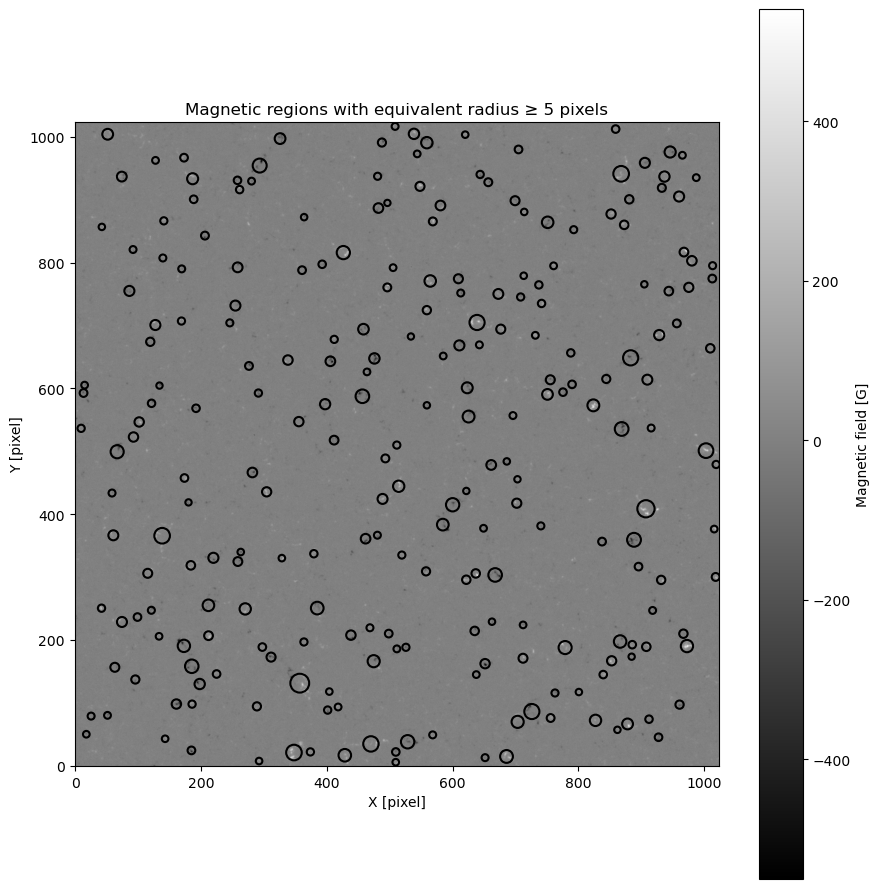

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ============================================================
# MAGNETOGRAMA + CÍRCULOS DE ÁREA EQUIVALENTE
# ============================================================

fig, ax = plt.subplots(figsize=(9, 9))

# Magnetograma
im = ax.imshow(
    mag_frame,
    origin="lower",
    cmap="gray",
    vmin=np.percentile(mag_frame,5)
)

# ------------------------------------------------------------
# Dibujar círculos de las regiones seleccionadas
# ------------------------------------------------------------

for region in selected_regions:

    circle = Circle(
        (region["x_center"], region["y_center"]),
        region["r_equivalent_pixels"],
        fill=False,
        linewidth=1.5
    )

    ax.add_patch(circle)

# ------------------------------------------------------------
# Formato
# ------------------------------------------------------------

plt.colorbar(
    im,
    ax=ax,
    label="Magnetic field [G]"
)

ax.set_xlabel("X [pixel]")
ax.set_ylabel("Y [pixel]")

ax.set_title(
    f"Magnetic regions with equivalent radius ≥ {min_radius} pixels"
)

plt.tight_layout()
plt.show()

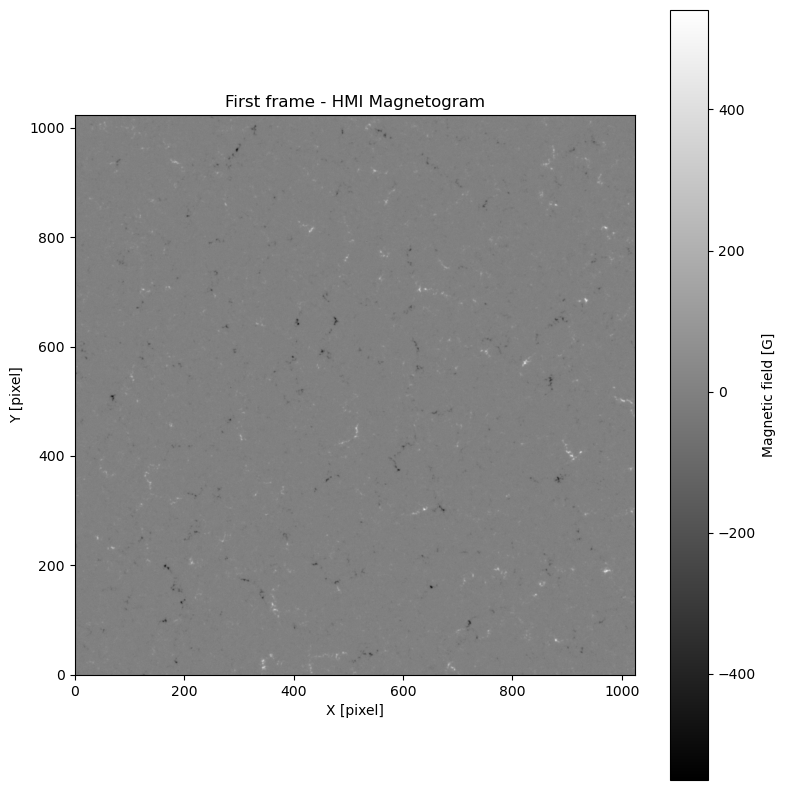

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.imshow(
    mag_frame,
    origin="lower",
    cmap="gray"
)

plt.colorbar(label="Magnetic field [G]")

plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("First frame - HMI Magnetogram")

plt.tight_layout()
plt.show()